## Hand Detection

This project utilizes a subset of the HaGRID dataset to train a Convolutional Neural Network (CNN) for hand detection in diverse real-world images. The model is trained to predict hand bounding boxes from RGB images, allowing it to localize the position and size of detected hands.

**How to run**

1. Download and place the HaGRID dataset (subset) in a `hagrid` folder (see file structure below)
2. Ensure the necessary dependencies are installed
>- pip install torch torchvision pillow matplotlib tqdm
3. Run cells in order
>- Imports, Load Data/Preprocessing, Models, Training/Testing, Results

**Dataset:** HaGRID Dataset

- Kapitanov, A., Kvanchiani, K., Nagaev, A., Kraynov, R., & Makhliarchuk, A. (2024). *HaGRID -- HAnd Gesture Recognition Image Dataset*. Proceedings of the IEEE/CVF Winter Conference on Applications of Computer Vision (WACV), 4572–4581. Dataset: <br>
https://github.com/hukenovs/hagrid

- This project uses a smaller subset of the HaGRID dataset containing 30,000 images for efficient training and experimentation. Dataset subset: <br>
https://huggingface.co/datasets/cj-mills/hagrid-sample-30k-384p/blob/main/README.md

**Folder structure**
```Models/
├── hagrid/
│   ├── ann_train_val/
│   │   ├── call.json
│   │   ├── dislike.json
│   │   └── ...
│   ├── hagrid_30k/
│   │   ├── train_val_call/
│   │   │   ├── image1.jpg
│   │   │   ├── image2.jpg
│   │   │   └── ...
│   │   ├── train_val_dislike/
│   │   │   └── ...
│   │   └── ...
└── HandDetection.ipynb

#### Imports

In [1]:
import os
import json
import random

import torch
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.patches as patches
import torchvision.transforms.functional as TF
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, random_split

#### Load Data / Preprocessing

In [2]:
class HaGRIDDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        # File paths
        img_root = os.path.join(root_dir, "hagrid_30k")
        ann_dir = os.path.join(root_dir, "ann_train_val")

        # Store samples and transforms
        self.samples = []
        self.transform = transform

        # Load annotation files
        for ann_file in sorted(os.listdir(ann_dir)):
            with open(os.path.join(ann_dir, ann_file)) as f:
                annotations = json.load(f)

            # Gesture folder
            gesture = ann_file.replace(".json", "")
            img_folder = os.path.join(img_root, f"train_val_{gesture}")

            # Store image and bounding boxes
            for img_uuid, ann in annotations.items():
                # Create image path
                img_path = os.path.join(img_folder, f"{img_uuid}.jpg")
                bboxes = ann.get("bboxes", [])
                for bbox in bboxes:
                    self.samples.append((img_path, bbox))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        # Load image and bounding box
        img_path, bbox = self.samples[i]
        image = Image.open(img_path).convert("RGB")
        bbox = list(bbox)

        # Apply random horizontal flip and transforms
        if random.random() < 0.5:
            image = TF.hflip(image)
            bbox[0] = 1.0 - bbox[0] - bbox[2]
        if self.transform:
            image = self.transform(image)

        return {"image": image, "bbox": torch.tensor(bbox, dtype=torch.float32)}

In [3]:
# Define image transforms
img_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load dataset
full_dataset = HaGRIDDataset("hagrid", transform=img_transforms)

# Train and Validation split
train_size = int(0.9 * len(full_dataset))
val_size   = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=0)

print(f"Train: {len(train_dataset)}  Val: {len(val_dataset)}")
print(f"Batches per epoch -- train: {len(train_loader)}  val: {len(val_loader)}")

Train: 559847  Val: 62206
Batches per epoch -- train: 34991  val: 3888


#### Model

In [4]:
class HandDetector(nn.Module):
    def __init__(self):
        super().__init__()

        # Feature extractor
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 256, 3, stride=2, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
        )

        # Spatial feature pooling
        self.pool = nn.AdaptiveAvgPool2d((7, 7))

        # Bounding box predictor
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 7 * 7, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 4)
        )

    def forward(self, x):
        # Extract image features
        x = self.features(x)
        x = self.pool(x)
        x = self.head(x)

        # Normalize output
        return torch.sigmoid(x)

In [5]:
# Check MPS support and use Apple GPU if available
print(torch.backends.mps.is_available())
print(torch.backends.mps.is_built())

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

True
True


In [6]:
# Initialize model
model = HandDetector().to(device)

print(model)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.0005)

HandDetector(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True,

In [7]:
def iou_loss(pred, gt):
    # Convert predicted box coordinates to x1, y1, x2, y2
    pred_x1 = pred[:, 0]
    pred_y1 = pred[:, 1]
    pred_x2 = pred[:, 0] + pred[:, 2]
    pred_y2 = pred[:, 1] + pred[:, 3]

    # Convert ground truth coordinates to x1, y1, x2, y2
    gt_x1 = gt[:, 0]
    gt_y1 = gt[:, 1]
    gt_x2 = gt[:, 0] + gt[:, 2]
    gt_y2 = gt[:, 1] + gt[:, 3]

    # Calculate intersection coordinates
    intersection_x1 = torch.max(pred_x1, gt_x1)
    intersection_y1 = torch.max(pred_y1, gt_y1)
    intersection_x2 = torch.min(pred_x2, gt_x2)
    intersection_y2 = torch.min(pred_y2, gt_y2)

    # Calculate intersection and union areas
    intersection_area = torch.clamp(intersection_x2 - intersection_x1, min=0) * torch.clamp(intersection_y2 - intersection_y1, min=0)
    pred_area = pred[:, 2] * pred[:, 3]
    gt_area = gt[:, 2]   * gt[:, 3]
    union_area = pred_area + gt_area - intersection_area + 1e-6

    # Compute IoU loss
    iou = intersection_area / union_area
    return 1.0 - iou.mean()

def compute_loss(pred, gt):
    # Combined losses
    coordinate_loss = F.smooth_l1_loss(pred, gt)
    iou = iou_loss(pred, gt)
    return 0.5 * coordinate_loss + 1.5 * iou

#### Training/Testing

In [8]:
def batch_iou(pred, gt):
    # Convert predicted boxes
    pred_x1 = pred[:, 0]
    pred_y1 = pred[:, 1]
    pred_x2 = pred[:, 0] + pred[:, 2]
    pred_y2 = pred[:, 1] + pred[:, 3]

    # Convert ground truth boxes
    gt_x1 = gt[:, 0]
    gt_y1 = gt[:, 1]
    gt_x2 = gt[:, 0] + gt[:, 2]
    gt_y2 = gt[:, 1] + gt[:, 3]

    # Intersection coordinates
    intersection_x1 = torch.max(pred_x1, gt_x1)
    intersection_y1 = torch.max(pred_y1, gt_y1)
    intersection_x2 = torch.min(pred_x2, gt_x2)
    intersection_y2 = torch.min(pred_y2, gt_y2)

    # Calculate IoU areas
    intersection_area = torch.clamp(intersection_x2 - intersection_x1, min=0) * torch.clamp(intersection_y2 - intersection_y1, min=0)
    pred_area = pred[:, 2] * pred[:, 3]
    gt_area = gt[:, 2]   * gt[:, 3]
    union_area = pred_area + gt_area - intersection_area + 1e-6

    # Compute mean IoU
    return (intersection_area / union_area).mean().item()

In [9]:
def train(model, loader, optimizer, device):
    # Set model to training mode
    model.train()

    # Track metrics
    total_loss = 0.0
    total_iou = 0.0

    # Progress bar
    train_bar = tqdm(loader, desc="Training", leave=False)

    for batch in train_bar:
        # Load data to device
        images = batch["image"].to(device)
        bboxes = batch["bbox"].to(device)

        # Forward pass
        preds = model(images)

        # Compute loss
        loss = compute_loss(preds, bboxes)

        # Backpropagation step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Metrics
        total_loss += loss.item()
        iou = batch_iou(preds.detach(), bboxes)
        total_iou += iou

        # Update progress bar
        train_bar.set_postfix(loss=loss.item(), iou=iou)

    return total_loss / len(loader), total_iou / len(loader)

In [10]:
def test(model, loader, device):
    # Set model to evaluation mode
    model.eval()

    # Track metrics
    total_loss = 0.0
    total_iou = 0.0

    # Progress bar
    test_bar = tqdm(loader, desc="Testing", leave=False)

    with torch.no_grad():
        for batch in test_bar:

            # Load data to device
            images = batch["image"].to(device)
            bboxes = batch["bbox"].to(device)

            # Forward pass
            preds = model(images)

            # Compute loss
            loss = compute_loss(preds, bboxes)

            # Metrics
            total_loss += loss.item()
            iou = batch_iou(preds, bboxes)
            total_iou += iou

            # Update progress bar
            test_bar.set_postfix(loss=loss.item(), iou=iou)

    return total_loss / len(loader), total_iou / len(loader)

In [11]:
# Metrics storage
train_losses, val_losses = [], []
train_ious, val_ious   = [], []

# Setup training variables
start_epoch = 0
epochs = 70
checkpoint_path = "checkpoint_hand_detector.pth"
best_model_path = "best_model_hand_detector.pth"
best_val_loss = float("inf")

# Load checkpoint if available
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])

    start_epoch = checkpoint["epoch"] + 1
    best_val_loss = checkpoint["best_val_loss"]
    train_losses = checkpoint["train_losses"]
    val_losses = checkpoint["val_losses"]
    train_ious = checkpoint["train_ious"]
    val_ious = checkpoint["val_ious"]

for epoch in range(start_epoch, epochs):
    # Train and validate model
    train_loss, train_iou = train(model, train_loader, optimizer, device)
    val_loss, val_iou = test(model, val_loader, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_ious.append(train_iou)
    val_ious.append(val_iou)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)

    # Save checkpoint
    torch.save({"epoch": epoch, "model_state": model.state_dict(), "optimizer_state": optimizer.state_dict(), "best_val_loss": best_val_loss,
                "train_losses": train_losses, "val_losses": val_losses, "train_ious": train_ious, "val_ious": val_ious}, checkpoint_path)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train IoU: {train_iou:.3f} | Val Loss: {val_loss:.4f} | Val IoU: {val_iou:.3f}")

#### Results

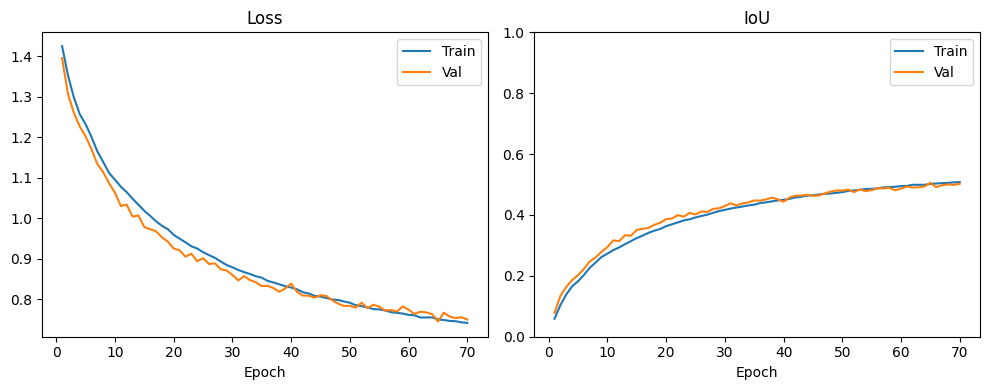

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
epochs_range = range(1, len(train_losses) + 1)

# loss curves
ax[0].plot(epochs_range, train_losses, label="Train")
ax[0].plot(epochs_range, val_losses,   label="Val")
ax[0].set_title("Loss")
ax[0].set_xlabel("Epoch")
ax[0].legend()

# IoU curves
ax[1].plot(epochs_range, train_ious, label="Train")
ax[1].plot(epochs_range, val_ious,   label="Val")
ax[1].set_title("IoU")
ax[1].set_xlabel("Epoch")
ax[1].set_ylim(0, 1)
ax[1].legend()

plt.tight_layout()
plt.show()

In [13]:
# Export model
model.load_state_dict(torch.load("best_model_hand_detector.pth", map_location=device))
model.eval()
torch.onnx.export(model, torch.randn(1, 3, 224, 224).to(device), "hand_detector.onnx", input_names=["input"], output_names=["bbox"], verbose=False)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 20},
            producer_name='pytorch',
            producer_version='2.12.0',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT,[1,3,224,224]>
            ),
            outputs=(
                %"bbox"<FLOAT,[1,4]>
            ),
            initializers=(
                %"features.0.weight"<FLOAT,[32,3,3,3]>{Tensor(...)},
                %"features.0.bias"<FLOAT,[32]>{Tensor(...)},
                %"features.3.weight"<FLOAT,[64,32,3,3]>{Tensor(...)},
                %"features.3.bias"<FLOAT,[64]>{Tensor(...)},
                %"features.6.weight"<FLOAT,[128,64,3,3]>{Tensor(...)},
                %"features.6.bias"<FLOAT,[128]>{Tensor(...)},
                %"features.9.weight"<FLOAT,[128,128,3,3]>{Tensor(...)},
                %"features.9.bias"<FLOAT,[128]>{Tensor(...)},
     